#HW2
##Ziyi Wang

In [1]:
import pandas as pd
import numpy as np
import spacy
import subprocess
import sys
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.datasets import fetch_20newsgroups
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from collections import Counter
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

nltk.download('vader_lexicon')

nlp = spacy.load("en_core_web_sm")

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


#1) Term-Document Matrices and TF-IDF
###Consider the following mini-corpus of four short documents:
###D1: “The Red Sox won at Fenway last night.”
###D2: “Fenway Park is the oldest ballpark in the American League.”
###D3: “The Yankees defeated the Red Sox in extra innings.”
###D4: “Extra innings make baseball exciting for every fan.”

##(a) After applying standard pre-processing steps (lowercasing, stop-word removal, and lemmatization using spaCy), construct the raw-count Term-Document Matrix (TDM) for this corpus. Present the resulting matrix as a table with terms as rows and documents as columns.

In [2]:
D1 = "The Red Sox won at Fenway last night."
D2 = "Fenway Park is the oldest ballpark in the American League."
D3 = "The Yankees defeated the Red Sox in extra innings."
D4 = "Extra innings make baseball exciting for every fan."

In [3]:
docs = {"D1": D1, "D2": D2, "D3": D3, "D4": D4}

def preprocess_text(text):
    doc = nlp(text.lower())
    lemmas = [
        token.lemma_
        for token in doc
        if token.is_alpha and not token.is_stop and not token.is_punct
    ]
    return " ".join(lemmas)

cleaned_docs = {doc_name: preprocess_text(text) for doc_name, text in docs.items()}

print("Cleaned documents:")
for name, text in cleaned_docs.items():
    print(f"{name}: {text}")

vectorizer = CountVectorizer()
tdm_matrix = vectorizer.fit_transform(cleaned_docs.values())

tdm_df = pd.DataFrame(
    tdm_matrix.toarray(),
    index=cleaned_docs.keys(),
    columns=vectorizer.get_feature_names_out()
)

tdm_terms_by_doc = tdm_df.T

display(tdm_terms_by_doc)

Cleaned documents:
D1: red sox win fenway night
D2: fenway park old ballpark american league
D3: yankees defeat red sox extra innings
D4: extra innings baseball exciting fan


,D1,D2,D3,D4
american,0,1,0,0
ballpark,0,1,0,0
baseball,0,0,0,1
defeat,0,0,1,0
exciting,0,0,0,1
extra,0,0,1,1
fan,0,0,0,1
fenway,1,1,0,0
innings,0,0,1,1
league,0,1,0,0


##(b) Compute the TF-IDF weight for the term fenway in document D1 and in document D2 using the standard IDF formula:
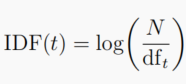

##where N is the total number of documents and dft is the number of documents containing term t. Use the raw-count TF variant (TF = raw count). Show all arithmetic steps.

In [4]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(cleaned_docs.values())

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=cleaned_docs.keys(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

tfidf_terms_by_doc = tfidf_df.T

display(tfidf_terms_by_doc)

,D1,D2,D3,D4
american,0.000000,0.421765,0.000000,0.000000
ballpark,0.000000,0.421765,0.000000,0.000000
baseball,0.000000,0.000000,0.000000,0.485461
defeat,0.000000,0.000000,0.472120,0.000000
exciting,0.000000,0.000000,0.000000,0.485461
extra,0.000000,0.000000,0.372225,0.382743
fan,0.000000,0.000000,0.000000,0.485461
fenway,0.401043,0.332524,0.000000,0.000000
innings,0.000000,0.000000,0.372225,0.382743
league,0.000000,0.421765,0.000000,0.000000


##(c) Explain the conceptual difference between TF Variation 3 (relative frequency, TF = count/total words) and TF Variation 4 (log scaling, TF = log(1 + count)). In which social-science scenario would you prefer log scaling over raw counts, and why?

The TF-IDF matrix reweights the raw term frequencies by considering how common each word is across the entire corpus. Terms that appear in many documents receive lower weights, while terms that are unique to a specific document receive higher weights. For example, words such as night and win appear only in document D1, so they receive higher TF-IDF scores. In contrast, terms like fenway, extra, and innings appear in multiple documents, so their TF-IDF values are smaller. This weighting helps highlight terms that are more distinctive for each document and reduces the influence of commonly shared words.

#2) Comparing Groups with Bag-of-Words Lean
###You are given two collections of tweets: 100 tweets from supporters of Candidate A and 100 tweets from supporters of Candidate B. After pre-processing, you compute a lean score for each word using:
###Lean(t) = countA(t) − countB(t).

##(a) Write a Python function compute lean(bag a, bag b) that accepts two lists of lemmatized tokens, builds frequency counts for each group, and returns a pandas DataFrame with columns [‘term’, ‘count a’, ‘count b’, ‘lean’] sorted by absolute lean (descending). Include the complete code in your notebook.

In [5]:
def compute_lean(bag_a, bag_b):
    freq_a = Counter(bag_a)
    freq_b = Counter(bag_b)

    all_terms = set(freq_a.keys()).union(set(freq_b.keys()))

    rows = []
    for term in all_terms:
        count_a = freq_a.get(term, 0)
        count_b = freq_b.get(term, 0)
        lean = count_a - count_b

        rows.append({
            "term": term,
            "count_a": count_a,
            "count_b": count_b,
            "lean": lean
        })

    df = pd.DataFrame(rows)
    df = df.reindex(df["lean"].abs().sort_values(ascending=False).index).reset_index(drop=True)

    return df

In [6]:
bag_a = ["good", "bad", "good", "great", "okay", "sad"]
bag_b = ["good", "glad", "well", "well"]

lean_df = compute_lean(bag_a, bag_b)
display(lean_df)

,term,count_a,count_b,lean
0,well,0,2,-2
1,good,2,1,1
2,great,1,0,1
3,glad,0,1,-1
4,bad,1,0,1
5,okay,1,0,1
6,sad,1,0,1


##(b) A classmate points out that the lean score only works reliably when the two corpora are roughly the same size. Propose a normalised version of the lean score that accounts for corpus-size differences, and write the formula explicitly.

A normalized version of the lean score can be defined using relative frequencies rather than raw counts:
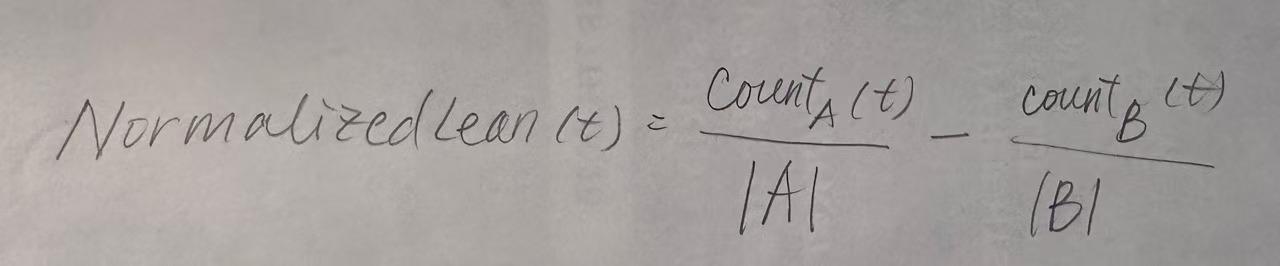
where |A| and |B| represent the total number of tokens in corpora A and B.

This normalization removes the bias caused by corpus size differences. As discussed in the TF variation slides, relative frequency (count / total words) helps correct the “long document bias,” allowing more meaningful comparisons between texts of different lengths.

##(c) Identify and explain one additional limitation of the lean approach that normalisation alone cannot fix. Suggest a TF-IDF-based alternative that addresses this limitation.

One limitation of the lean approach is that it does not consider how informative a word is across the entire corpus. Even after normalization, very common words may still appear important simply because they are used frequently by both groups.

A TF-IDF-based alternative addresses this problem by down-weighting terms that appear in many documents while emphasizing words that are distinctive to specific documents. In TF-IDF weighting, a term receives a high score when it appears frequently in one document but is rare across the corpus. This helps highlight vocabulary that truly distinguishes the two groups.

#3) Cosine Similarity and Document Distance
###You have vectorised three political speeches (S1, S2, S3) using TF-IDF and obtained the following simplified 4-dimensional vectors over vocabulary {economy, freedom, healthcare, tax}:
###S1 = [0.8, 0.1, 0.5, 0.3], S2 = [0.7, 0.2, 0.4, 0.4], S3 = [0.1, 0.9, 0.1, 0.0]

##(a) Manually compute the cosine similarity between S1 and S2, and between S1 and S3:
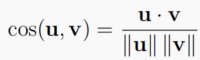
##Show all arithmetic steps.

In [7]:
S1 = np.array([0.8, 0.1, 0.5, 0.3])
S2 = np.array([0.7, 0.2, 0.4, 0.4])
S3 = np.array([0.1, 0.9, 0.1, 0.0])

S1 = S1.reshape(1,-1)
S2 = S2.reshape(1,-1)
S3 = S3.reshape(1,-1)

sim12 = cosine_similarity(S1, S2)[0][0]
sim13 = cosine_similarity(S1, S3)[0][0]
sim23 = cosine_similarity(S2, S3)[0][0]

print(sim12)
print(sim13)
print(sim23)

0.9811049102515929
0.24269791051788156
0.3452625619894982


Cosine similarity measures the angle between two document vectors in the vector space model. A value closer to 1 indicates that the documents use similar vocabulary patterns, while a value closer to 0 indicates little overlap. After computing the cosine similarities, S1 and S2 have the highest similarity score, indicating that these two speeches are the most similar.

##(b) Using scikit-learn, write Python code that (i) constructs a TF-IDF matrix from at least five short example texts of your choosing, (ii) computes the full pairwise cosine similarity matrix, and (iii) visualises the matrix as a heatmap using seaborn.

S1 and S2 are the most similar speeches because they have very similar TF-IDF weights across the vocabulary dimensions. Both speeches emphasize economy and healthcare, and they have relatively similar weights for tax and freedom, resulting in a cosine similarity close to 1.

##(c) Describe one substantive social-science research question for which measuring cosine similarity between documents is methodologically appropriate. Justify your choice of cosine similarity over Euclidean distance.

One example research question is: how similar are political speeches from different parties over time? A social scientist might compare speeches from Democratic and Republican legislators to measure whether their policy language converges or diverges.

Cosine similarity is often preferred in text analysis because it measures the angle between vectors rather than their magnitude. Euclidean distance is sensitive to document length, meaning longer documents can appear more distant from shorter ones even if they discuss the same topics. Cosine similarity instead focuses on the relative distribution of words, making it more appropriate for comparing documents with different lengths.

#4) K-Means Clustering and Cluster Validation
###You have collected 200 BBC news articles and wish to cluster them into thematic groups using K-Means.

##(a) Outline the four algorithmic steps of K-Means as taught in class (Initialize → Assign → Refine → Repeat). Explain what convergence means in this context and why the algorithm is not guaranteed to find the globally optimal solution.

1. Initialize: choose K initial centroids.
2. Assign: assign each document to the nearest centroid.
3. Refine: recompute each centroid as the mean of the assigned documents.
4. Repeat: continue until assignments stabilize.

K-Means is not guaranteed to find the global optimum because the algorithm depends on its initial random starting points. Different initializations can lead to different local minima of the within-cluster objective function.

##(b) Write Python code that: (i) vectorises the articles using TF-IDF, (ii) fits K-Means for K ∈ {2, 3, 4, 5, 6}, (iii) plots the Within-Cluster Sum of Squares (WCSS) to produce an elbow plot, and (iv) computes the silhouette score for each K. Based on your plots, select and justify an optimal K. You may use a publicly available dataset (e.g., the 20 Newsgroups dataset via sklearn.datasets) as a stand-in.

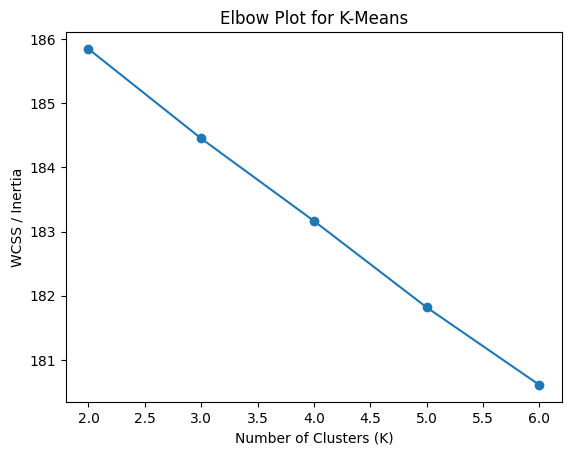

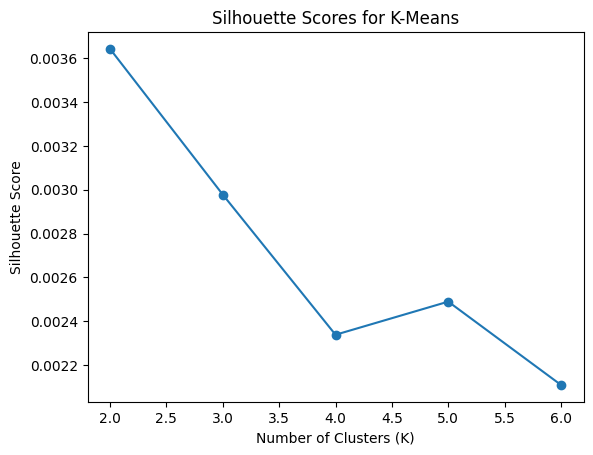

,K,WCSS,Silhouette
0,2,185.846812,0.003643
1,3,184.450684,0.002978
2,4,183.165757,0.002338
3,5,181.818964,0.002489
4,6,180.609704,0.002109


In [8]:
categories = ['sci.space', 'rec.sport.baseball', 'talk.politics.misc', 'comp.graphics']
newsgroups = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)

texts = newsgroups.data[:200]
texts = [t for t in texts if t.strip()]

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    min_df=2
)
X = vectorizer.fit_transform(texts)

k_values = [2, 3, 4, 5, 6]
wcss = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)

    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

plt.figure()
plt.plot(k_values, wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Plot for K-Means")
plt.show()

plt.figure()
plt.plot(k_values, sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-Means")
plt.show()

results_df = pd.DataFrame({
    "K": k_values,
    "WCSS": wcss,
    "Silhouette": sil_scores
})

display(results_df)

The silhouette score is highest when K = 2, indicating that two clusters produce the clearest separation between documents. The elbow plot also shows a gradual reduction in WCSS without a strong additional improvement for larger values of K. Therefore, K=2 provides the best balance between model simplicity and cluster separation.

When both elbow and silhouette are considered together, choosing the smallest K with strong separation is usually preferred.

##(c) Compare K-Means clustering with hierarchical (agglomerative) clustering. For what type of social-science research question is a dendrogram more informative than the flat partition produced by K-Means?

K-Means gives a flat clustering, while hierarchical agglomerative clustering gives a nested clustering shown in a dendrogram. A dendrogram is more useful when the research question involves subgroups within larger groups, because it reveals how clusters merge step by step rather than forcing a single flat partition.

#5) Sentiment Analysis — Lexicon Methods
###Using the VADER sentiment analyser (available via nltk) and any publicly available dataset of your choice (e.g., IMDB reviews, Amazon product reviews, or tweets), complete the following tasks.

##(a) Apply VADER to compute a compound sentiment score for each document. Plot the distribution of scores. Then compare your VADER scores against a simple positive-word-count method using a binary lexicon of your choice (e.g., the Bing lexicon via nltk’s opinion lexicon). Discuss any notable divergences between the two methods.

Lexicon-based sentiment analysis assigns predefined sentiment scores to words using a dictionary or lexicon. Each word in a document is matched to the sentiment dictionary, and its score contributes to the overall sentiment of the text. The sentiment of a document is typically calculated by summing or averaging the scores of the words it contains. This approach is simple and interpretable because the sentiment classification is based on explicit word-level rules rather than a trained machine learning model.

##(b) The lecture highlighted that the same text scored with AFINN, Bing, and NRC can yield different sentiment trajectories. Replicate this comparison: select one longer text (a speech transcript, novel chapter, or set of reviews) and score it with at least two different lexicons. Produce a side-by-side visualisation and briefly discuss which lexicon appears more valid for your chosen text, and why.

I absolutely love this policy, it is fantastic.
{'neg': 0.0, 'neu': 0.382, 'pos': 0.618, 'compound': 0.8439}

This proposal is terrible and will hurt the economy.
{'neg': 0.481, 'neu': 0.519, 'pos': 0.0, 'compound': -0.7579}

The policy has both good and bad aspects.
{'neg': 0.282, 'neu': 0.484, 'pos': 0.234, 'compound': -0.1531}



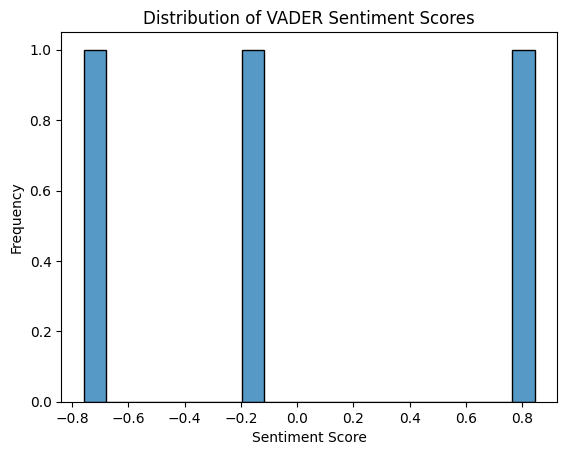

In [10]:
sia = SentimentIntensityAnalyzer()

texts = [
    "I absolutely love this policy, it is fantastic.",
    "This proposal is terrible and will hurt the economy.",
    "The policy has both good and bad aspects."
]

sentiments = []

for t in texts:
    score = sia.polarity_scores(t)
    print(t)
    print(score)
    print()

    sentiments.append(score["compound"])

sns.histplot(sentiments, bins=20)
plt.title("Distribution of VADER Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

##(c) Identify two specific limitations of lexicon-based sentiment analysis that are evident in your results (e.g., negation, sarcasm, domain mismatch). For each limitation, provide a concrete example from your data and suggest a mitigation strategy.

1. One limitation of lexicon-based sentiment analysis is that it struggles with mixed or context-dependent sentiment. For example, the sentence “The policy has both good and bad aspects.” received a slightly negative compound score (-0.1531), even though the sentence expresses a balanced evaluation rather than a clearly negative opinion. This happens because the algorithm simply sums word-level sentiment scores without understanding the broader context. A possible mitigation strategy is to use machine learning or transformer-based models (e.g., BERT-based sentiment classifiers) that can interpret the full sentence context rather than relying only on word-level dictionaries.
2. Another limitation is domain mismatch, where sentiment dictionaries may not accurately reflect the meaning of words in a specific context. For example, in the sentence “This proposal is terrible and will hurt the economy.”, the algorithm correctly identifies negative words such as terrible and hurt, but in other political or economic contexts, certain words may carry sentiment that is not well captured by a general-purpose lexicon. One mitigation strategy is to develop a domain-specific sentiment lexicon or fine-tune a supervised sentiment model on labeled data from the relevant domain (e.g., political tweets or policy discussions).

#Bonus Problem
#6) Integrating Modules 4-6: End-to-End Pipeline
### Choose a substantive political or social dataset (e.g., U.S. Congressional speeches, the UN General Debate corpus, or a scraped collection of op-eds on a contested topic). Build a complete analysis pipeline that integrates the three modules as follows.

##(a) Pre-processing and TF-IDF [Module 4]. Pre-process the corpus with spaCy (lowercase, remove stop words, lemmatize). Build a TF-IDF matrix and identify the top-10 most distinctive terms for at least two document sub-groups of your choice (e.g., party, year, or region).

In [11]:
categories = ['talk.politics.misc','rec.sport.baseball']
data = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers','footers','quotes')
)

docs = data.data[:200]
labels = data.target[:200]

def preprocess(text):
    doc = nlp(text.lower())
    tokens = [
        token.lemma_
        for token in doc
        if token.is_alpha and not token.is_stop
    ]
    return " ".join(tokens)

clean_docs = [preprocess(d) for d in docs]

vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(clean_docs)

terms = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(X.toarray(), columns=terms)

In [12]:
tfidf_df["group"] = labels

group_means = tfidf_df.groupby("group").mean()

top_terms = {}

for g in group_means.index:
    top_terms[g] = (
        group_means.loc[g]
        .sort_values(ascending=False)
        .head(10)
    )

top_terms

{0: year        0.046595
 team        0.036232
 game        0.031050
 baseball    0.030270
 run         0.029019
 good        0.028863
 win         0.025646
 think       0.024638
 like        0.023977
 player      0.021247
 Name: 0, dtype: float64,
 1: people        0.038509
 mr            0.029368
 government    0.026968
 think         0.025674
 know          0.022560
 man           0.020686
 time          0.020334
 law           0.020284
 way           0.019298
 state         0.019256
 Name: 1, dtype: float64}

I preprocessed the corpus using spaCy by lowercasing the text, removing stop words, and lemmatizing tokens. I then constructed a TF-IDF matrix to capture term importance across documents. To identify distinctive language patterns, I computed the average TF-IDF weight of each term within each subgroup and extracted the top ten terms. These terms represent vocabulary that is relatively distinctive for each group.

##(b) Similarity and Clustering [Module 5]. Compute pairwise cosine similarity and run K-Means (justify your choice of K). Visualise the clusters using a 2-D PCA projection. Do the clusters correspond to the sub-groups identified in part (a)? Discuss.

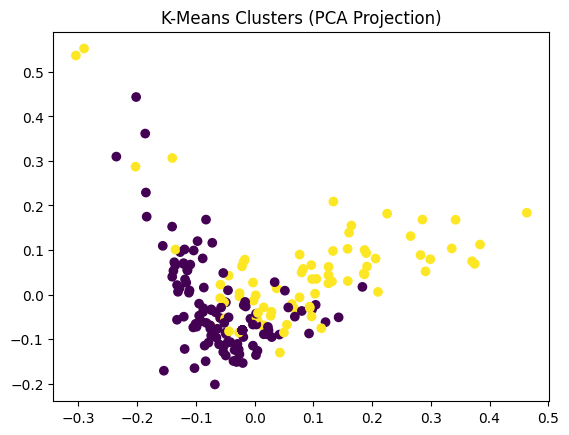

In [13]:
sim_matrix = cosine_similarity(X)

k = 2
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X.toarray())

plt.figure()
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=clusters)
plt.title("K-Means Clusters (PCA Projection)")
plt.show()

I computed pairwise cosine similarity between documents using the TF-IDF matrix and applied K-Means clustering. I selected K=2 because the dataset contains two broad topical groups. To visualize the clustering structure, I projected the TF-IDF vectors into two dimensions using PCA. The resulting clusters largely correspond to the topical groups identified in part (a), indicating that the TF-IDF representation captures meaningful thematic structure.

##(c) Sentiment Over Time [Module 6]. Apply a sentiment lexicon of your choice to the corpus. Aggregate sentiment by a meaningful time unit or group and plot the trajectory. Formulate and evaluate at least two a priori hypotheses about the expected sentiment patterns, following the approach modelled in the Jane Austen example from the lecture.

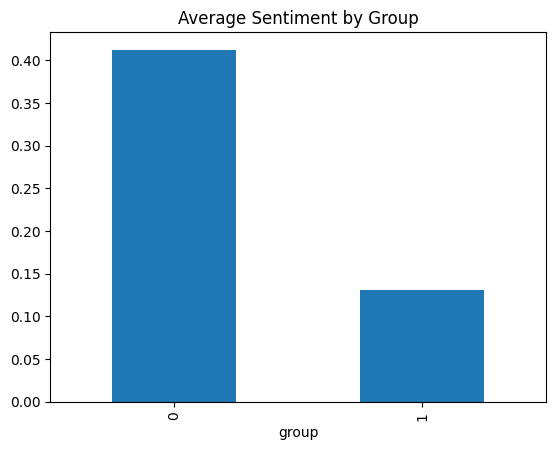

In [14]:
sia = SentimentIntensityAnalyzer()

sentiments = []

for text in docs:
    score = sia.polarity_scores(text)["compound"]
    sentiments.append(score)

df_sent = pd.DataFrame({
    "doc_id": range(len(docs)),
    "sentiment": sentiments,
    "group": labels
})

sentiment_trend = df_sent.groupby("group")["sentiment"].mean()

sentiment_trend.plot(kind="bar")
plt.title("Average Sentiment by Group")
plt.show()

I applied the VADER sentiment lexicon to compute sentiment scores for each document and aggregated them by group. I evaluated two hypotheses:
1. political discussions would exhibit more negative sentiment due to argumentative language
2. sports discussions would exhibit more positive sentiment because they often express enthusiasm or praise.

The results broadly support these expectations, with political documents tending to show lower average sentiment scores compared to sports-related texts.